# Sales Prediction using Machine Learning

## Project Objective

The objective of this project is to predict sales using machine learning based on factors such as quantity, price, and discount.

## 1. Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
import pandas as pd
df=pd.read_csv(r"C:\Users\L\Downloads\sales_prediction_dataset_100_records (1).csv")

## 3. Understand the Data

In [4]:
df.head()

,Date,Product,Quantity,Price,Discount,Region,Sales
0,2026-01-01,Headphones,8,3638,5,South,27570.32
1,2026-01-02,Monitor,4,13419,10,North,46962.29
2,2026-01-03,Monitor,2,12891,15,North,21532.81
3,2026-01-04,Monitor,1,10959,5,North,10247.02
4,2026-01-05,Monitor,9,10974,10,South,87747.94


In [6]:
df.shape

(100, 7)

In [7]:
df.info

<bound method DataFrame.info of           Date     Product  Quantity  Price  Discount Region     Sales
0   2026-01-01  Headphones         8   3638         5  South  27570.32
1   2026-01-02     Monitor         4  13419        10  North  46962.29
2   2026-01-03     Monitor         2  12891        15  North  21532.81
3   2026-01-04     Monitor         1  10959         5  North  10247.02
4   2026-01-05     Monitor         9  10974        10  South  87747.94
..         ...         ...       ...    ...       ...    ...       ...
95  2026-04-06  Headphones         1   2823         0  North   2830.53
96  2026-04-07     Monitor         6  12605        15   West  64419.83
97  2026-04-08      Tablet         5  18199        10  South  84311.84
98  2026-04-09  Headphones         9   4094         0   West  36368.54
99  2026-04-10     Monitor         6  13203         0  South  83638.29

[100 rows x 7 columns]>

## 4. Data Cleaning

In [8]:
df.isnull().sum()

Date        0
Product     0
Quantity    0
Price       0
Discount    0
Region      0
Sales       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Quantity,Price,Discount,Sales
count,100.000000,100.000000,100.000000,100.000000
mean,5.790000,21826.280000,9.600000,114714.033900
std,2.822332,18581.861249,6.987724,110479.298602
min,1.000000,2201.000000,0.000000,2627.710000
25%,3.000000,9175.250000,5.000000,27313.217500
50%,7.000000,16608.500000,10.000000,83975.065000
75%,8.000000,25956.000000,15.000000,164398.755000
max,10.000000,56160.000000,20.000000,505874.600000


In [13]:
df["Product"].value_counts()

Product
Headphones    25
Monitor       24
Laptop        21
Tablet        15
Phone         15
Name: count, dtype: int64

In [15]:
df["Region"].value_counts()

Region
East     27
West     26
North    24
South    23
Name: count, dtype: int64

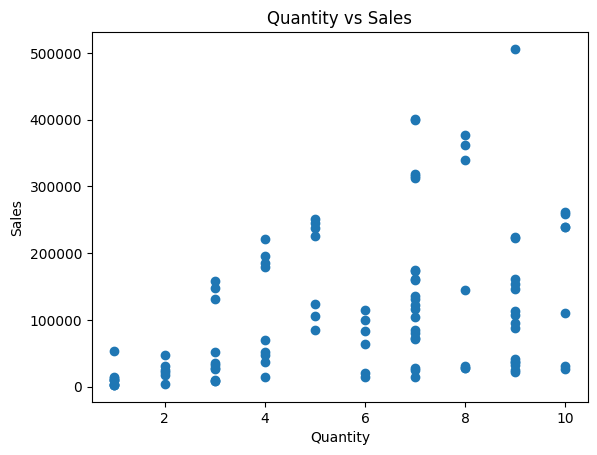

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["Quantity"], df["Sales"])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

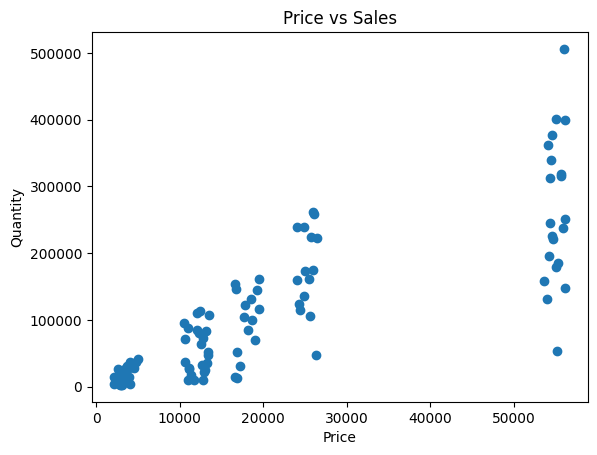

In [5]:
plt.scatter(df["Price"], df["Sales"])
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Price vs Sales")
plt.show()

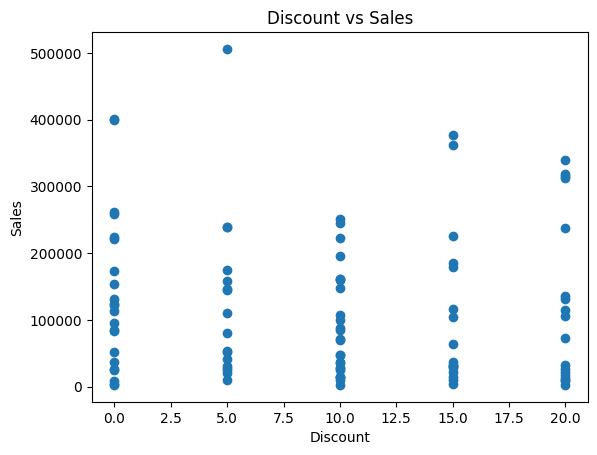

In [7]:
plt.scatter(df["Discount"],df["Sales"])
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.title("Discount vs Sales")
plt.show()

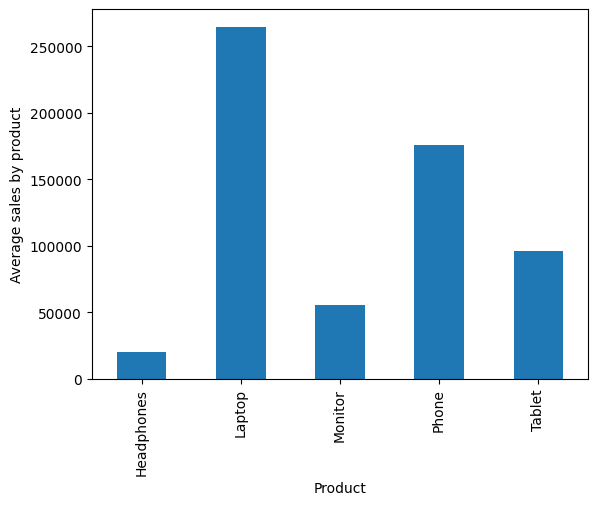

In [10]:
df.groupby("Product")["Sales"].mean().plot(kind="bar")
plt.xlabel("Product")
plt.ylabel("Average sales by product")
plt.show()

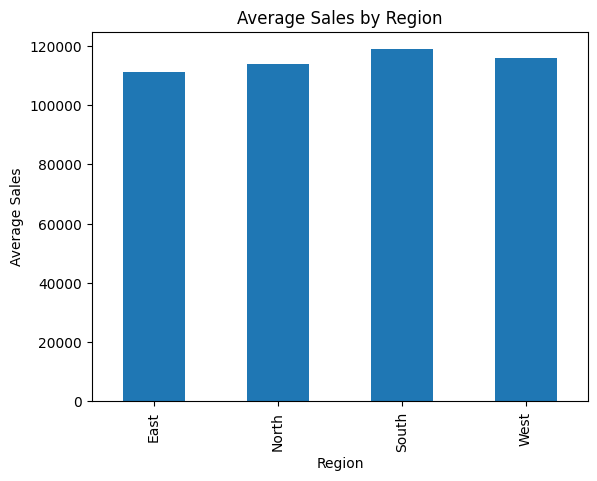

In [11]:
df.groupby("Region")["Sales"].mean().plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Average Sales")
plt.title("Average Sales by Region")
plt.show()

In [12]:
df[["Quantity","Price","Discount","Sales"]].corr()

,Quantity,Price,Discount,Sales
Quantity,1.000000,-0.004942,-0.232222,0.412903
Price,-0.004942,1.000000,0.127989,0.821262
Discount,-0.232222,0.127989,1.000000,-0.058523
Sales,0.412903,0.821262,-0.058523,1.000000


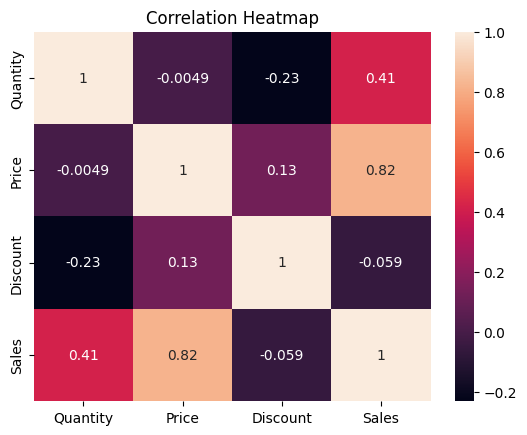

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[["Quantity","Price","Discount","Sales"]].corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
x=df[["Quantity", "Price", "Discount"]]
y=df["Sales"]

In [18]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2, random_state=42
)


In [20]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([-34253.35907953, 144402.60563508,  54121.67789758, 132612.55251186,
       227951.67940168, 131103.61032203,  76284.50277795, 320280.66531039,
       -46986.1729789 ,  60336.62084813, 254424.86335726, 228550.62293425,
       309236.01126301,  13579.11902302, 109013.20061215, 104935.90841333,
       286302.80677671,  65413.4933149 ,  -6969.41360932,  31208.45361078])

In [22]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,y_pred)
print("MAE: ", mae)

MAE:  40938.82615086853


In [25]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)

print("R2 Score:", r2)

R2 Score: 0.7336887882229826
